# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [451]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [452]:
# cargar archivos

orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv') 
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')


In [453]:
# explorar datasets
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [454]:
orders_work = orders.copy()

In [455]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [456]:
catalog_work = catalog.copy()

In [457]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


In [458]:
marketing_work = marketing.copy()

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

**📐Funciones reutilizables**

- **value_counts_multi :** identifica y divide las columnas del dataframe entre categóricas y numéricas
- **clean_text :** limpia el texto de la columna, convirtiendo a mayúsculas y sin espacios
- **fill_unknown :** reemplaza nulos por la categoría "DESCONOCIDO"
- **format_dates :** estandariza a formato fecha
- **float_to_int :** sustituye formato decimal por entero
- **remove_duplicates :** elimina duplicados
- **impute_nans :** imputa nulos por mediana
- **segment_customer :** clasifica clientes por volumen de venta (para descartar posibles outliers)
- **segment_product :** clasifica productos por costo unitario

In [459]:
# división de columnas por categóricas y numéricas.
def value_counts_multi(df, cols):
    numericas = df[cols].select_dtypes(include="number").columns
    categoricas = df[cols].select_dtypes(exclude="number").columns

    # Descripción de columnas
    print("\n====== CATEGÓRICAS ======")
    for col in categoricas:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False))

    print("\n====== NUMÉRICAS ======")
    for col in numericas:
        print(f"\n--- {col} ---")
        print(df[col].describe())

In [460]:
#limpieza de texto- mayúsculas y sin espacios

def clean_text(df, cols):
    for col in cols:
        if col in df.columns:
            
            df[col] = df[col].apply(
                lambda x: x.strip().upper() if isinstance(x, str) else x
            )
            
            # mostrar conteos (incluyendo nulos)
            print(f"\n--- {col} ---")
            print(df[col].value_counts(dropna=False))
        
        else:
            print(f"⚠️ Columna no encontrada: {col}")



In [461]:
# reemplazar nulos por "DESCONOCIDO"
def fill_unknown(df, cols, valor="DESCONOCIDO"):
    for col in cols:
        if col in df.columns:
            
            df[col] = df[col].fillna(valor)

            # Mostrar conteos
            print(f"\n--- {col} ---")
            print(df[col].value_counts(dropna=False))
        
        else:
            print(f"⚠️ Columna no encontrada: {col}")

In [462]:
# cambiar formato a fecha
def format_dates(df, cols, formato=None):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format=formato, errors="coerce")

            print(f"\n--- {col} ---")
            print(df[col].head())
            print(f"Nulos generados: {df[col].isna().sum()}")
        
        else:
            print(f"⚠️ Columna no encontrada: {col}")

In [463]:
# cambiar formato de decimal a entero
def float_to_int(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype("Int64")
        else:
            print(f"⚠️ Columna no encontrada: {col}")
    return df


In [464]:
# eliminar duplicados
def remove_duplicates(df, cols=None, keep="first"):
    before = len(df)
    
    df_clean = df.drop_duplicates(subset=cols, keep=keep).reset_index(drop=True)
    
    after = len(df_clean)

    print(f"Rows before: {before}")
    print(f"Rows after: {after}")
    print(f"Duplicates removed: {before - after}")

    return df_clean

In [465]:
# reemplazar nulos numéricos por mediana

def impute_nans(df, columnas, metodo="median"):
    
    for col in columnas:
        if metodo == "median":
            valor = df[col].median()
        elif metodo == "mean":
            valor = df[col].mean()
        else:
            raise ValueError("Método no soportado. Usa 'median' o 'mean'.")
        
        df[col] = df[col].fillna(valor)
    
    return df


In [466]:
#clasificación de clientes para descartar que se trata de outlier
def segment_customer(df, column):
    def classify(x):
        if x <= 2:
            return "RETAIL"
        elif x <= 100:
            return "SEMI-WHOLESALE"
        else:
            return "WHOLESALE"
    
    df = df.copy()
    df["customer_type"] = df[column].apply(classify)
    
    return df


In [467]:
#clasificación de productos por costo unitario
def segment_product(df, column):
    def classify(x):
        if pd.isna(x):
            return "UNKNOWN"
        elif x <= 25:
            return "LOW-COST"
        elif x <= 150:
            return "MID-RANGE"
        else:
            return "PREMIUM"
    
    df = df.copy()
    df["product_segment"] = df[column].apply(classify)
    
    return df

**📊 DataFrame: orders_work**
*🧹 Limpieza y preparación de datos*

- Identificación y división de las columnas en variables categóricas y numéricas  
- Limpieza de texto en columnas categóricas (conversión a mayúsculas y eliminación de espacios)  
- Reemplazo de valores nulos por la categoría "DESCONOCIDO" en las columnas `pais`, `fuente_referencia`, `nombre_producto` y `categoría_producto`
- Estandarización de la columna `fecha_hora_pedido` a tipo fecha  
- Conversión de la columna "cantidad" de formato decimal a entero  
- Eliminación de registros duplicados  
- Clasificación de clientes por volumen de venta (para detección de posibles outliers)   
- Eliminación de valores negativos en `cantidad`, `precio_unitario` y `monto_total` (debido a su baja frecuencia y falta de sentido en el contexto del análisis)  
- Cálculo del IQR para la toma de decisiones respecto a outliers  


In [468]:
value_counts_multi(
    orders_work,
    [
        "pais",
        "dispositivo",
        "fuente_referencia",
        "nombre_producto",
        "categoria_producto",
        "cantidad",
        "precio_unitario",
        "monto_descuento",
    ]
)


====== CATEGÓRICAS ======

--- pais ---
Colombia     7520
Mexico       7502
Argentina    7291
mexico        865
colombia      823
argentina     799
NaN           300
Name: pais, dtype: int64

--- dispositivo ---
desktop    12759
mobile     12321
NaN           20
Name: dispositivo, dtype: int64

--- fuente_referencia ---
social         8428
organic        8329
paid_search    8313
NaN              30
Name: fuente_referencia, dtype: int64

--- nombre_producto ---
Vacuum-Pro-Black        4199
Blender-XL-Red          4195
Jacket-Winter-M         4192
Sneakers-Urban-42       4160
Laptop-Gaming-16GB      2794
Tablet-Standard-64GB    2780
Phone-Pro-128GB         2750
NaN                       30
Name: nombre_producto, dtype: int64

--- categoria_producto ---
Hogar          8385
Moda           8323
Electronica    8312
NaN              80
Name: categoria_producto, dtype: int64

====== NUMÉRICAS ======

--- cantidad ---
count    25050.000000
mean         7.092735
std        296.277003
min       

In [469]:
clean_text(
    orders_work,
    ["pais", "dispositivo", "fuente_referencia","nombre_producto","categoria_producto",]
)


--- pais ---
MEXICO       8367
COLOMBIA     8343
ARGENTINA    8090
NaN           300
Name: pais, dtype: int64

--- dispositivo ---
DESKTOP    12759
MOBILE     12321
NaN           20
Name: dispositivo, dtype: int64

--- fuente_referencia ---
SOCIAL         8428
ORGANIC        8329
PAID_SEARCH    8313
NaN              30
Name: fuente_referencia, dtype: int64

--- nombre_producto ---
VACUUM-PRO-BLACK        4199
BLENDER-XL-RED          4195
JACKET-WINTER-M         4192
SNEAKERS-URBAN-42       4160
LAPTOP-GAMING-16GB      2794
TABLET-STANDARD-64GB    2780
PHONE-PRO-128GB         2750
NaN                       30
Name: nombre_producto, dtype: int64

--- categoria_producto ---
HOGAR          8385
MODA           8323
ELECTRONICA    8312
NaN              80
Name: categoria_producto, dtype: int64


In [470]:
fill_unknown(
    orders_work,
    ["pais", "dispositivo", "fuente_referencia","nombre_producto","categoria_producto"]
)


--- pais ---
MEXICO         8367
COLOMBIA       8343
ARGENTINA      8090
DESCONOCIDO     300
Name: pais, dtype: int64

--- dispositivo ---
DESKTOP        12759
MOBILE         12321
DESCONOCIDO       20
Name: dispositivo, dtype: int64

--- fuente_referencia ---
SOCIAL         8428
ORGANIC        8329
PAID_SEARCH    8313
DESCONOCIDO      30
Name: fuente_referencia, dtype: int64

--- nombre_producto ---
VACUUM-PRO-BLACK        4199
BLENDER-XL-RED          4195
JACKET-WINTER-M         4192
SNEAKERS-URBAN-42       4160
LAPTOP-GAMING-16GB      2794
TABLET-STANDARD-64GB    2780
PHONE-PRO-128GB         2750
DESCONOCIDO               30
Name: nombre_producto, dtype: int64

--- categoria_producto ---
HOGAR          8385
MODA           8323
ELECTRONICA    8312
DESCONOCIDO      80
Name: categoria_producto, dtype: int64


In [471]:
format_dates(
    orders_work,
    ["fecha_hora_pedido"]
)


--- fecha_hora_pedido ---
0   2025-05-22
1   2025-06-15
2   2025-05-02
3   2025-06-09
4   2025-03-30
Name: fecha_hora_pedido, dtype: datetime64[ns]
Nulos generados: 0


In [472]:
orders_work = remove_duplicates(orders_work)

Rows before: 25100
Rows after: 25000
Duplicates removed: 100


In [473]:
orders_work = float_to_int(
    orders_work,
    ["cantidad"]
)

In [474]:
orders_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25000 non-null  object        
 1   id_usuario          25000 non-null  object        
 2   fecha_hora_pedido   25000 non-null  datetime64[ns]
 3   pais                25000 non-null  object        
 4   dispositivo         25000 non-null  object        
 5   fuente_referencia   25000 non-null  object        
 6   nombre_producto     25000 non-null  object        
 7   categoria_producto  25000 non-null  object        
 8   cantidad            24950 non-null  Int64         
 9   precio_unitario     24950 non-null  float64       
 10  monto_descuento     24950 non-null  float64       
 11  monto_total         25000 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(3), object(7)
memory usage: 2.3+ MB


In [475]:
orders_work.isnull().mean().sort_values(ascending=False)

cantidad              0.002
precio_unitario       0.002
monto_descuento       0.002
id_pedido             0.000
id_usuario            0.000
fecha_hora_pedido     0.000
pais                  0.000
dispositivo           0.000
fuente_referencia     0.000
nombre_producto       0.000
categoria_producto    0.000
monto_total           0.000
dtype: float64

In [476]:
(orders_work[["cantidad", "precio_unitario", "monto_total"]] < 0).sum()

cantidad           4
precio_unitario    0
monto_total        4
dtype: int64

In [477]:
orders_work = orders_work[
    (orders_work["cantidad"] >= 0) &
    (orders_work["precio_unitario"] >= 0) &
    (orders_work["monto_total"] >= 0)
]

In [478]:
(orders_work[["cantidad", "precio_unitario", "monto_total"]] < 0).sum()

cantidad           0
precio_unitario    0
monto_total        0
dtype: int64

In [479]:
cols = ["cantidad", "precio_unitario", "monto_total"]

medianas_before = orders[cols].median()
medianas_after = orders_work[cols].median()

pd.DataFrame({
    "mediana_antes": medianas_before,
    "mediana_despues": medianas_after
})

,mediana_antes,mediana_despues
cantidad,2.000,2.000
precio_unitario,258.715,258.795
monto_total,341.750,341.605


In [480]:

Q1 = orders_work["cantidad"].quantile(0.25)
Q3 = orders_work["cantidad"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

outliers = orders_work[
    (orders_work["cantidad"] < limite_inferior) |
    (orders_work["cantidad"] > limite_superior)
]

outliers


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
3521,order_3521,user_5812,2025-02-03,MEXICO,MOBILE,PAID_SEARCH,LAPTOP-GAMING-16GB,ELECTRONICA,10000,43.14,0.0,431400.0
3522,order_3522,user_3575,2025-03-29,ARGENTINA,DESKTOP,SOCIAL,LAPTOP-GAMING-16GB,ELECTRONICA,10000,280.55,0.0,2805500.0
3586,order_3586,user_3380,2025-02-03,MEXICO,MOBILE,PAID_SEARCH,LAPTOP-GAMING-16GB,ELECTRONICA,10000,490.35,0.0,4903500.0
3643,order_3643,user_4440,2025-01-07,COLOMBIA,DESKTOP,SOCIAL,LAPTOP-GAMING-16GB,ELECTRONICA,10000,238.15,0.0,2381500.0
3656,order_3656,user_884,2025-01-01,ARGENTINA,MOBILE,ORGANIC,LAPTOP-GAMING-16GB,ELECTRONICA,20000,297.66,0.0,5953200.0
3668,order_3668,user_7270,2025-06-24,MEXICO,MOBILE,PAID_SEARCH,LAPTOP-GAMING-16GB,ELECTRONICA,20000,348.31,0.0,6966200.0
3689,order_3689,user_6566,2025-06-16,MEXICO,DESKTOP,PAID_SEARCH,LAPTOP-GAMING-16GB,ELECTRONICA,10000,87.69,0.0,876900.0
3722,order_3722,user_4723,2025-05-09,ARGENTINA,MOBILE,PAID_SEARCH,LAPTOP-GAMING-16GB,ELECTRONICA,20000,442.01,0.0,8840200.0
3726,order_3726,user_2536,2025-02-12,COLOMBIA,DESKTOP,SOCIAL,LAPTOP-GAMING-16GB,ELECTRONICA,20000,290.85,0.0,5817000.0
3748,order_3748,user_7096,2025-02-23,MEXICO,DESKTOP,ORGANIC,LAPTOP-GAMING-16GB,ELECTRONICA,10000,336.93,0.0,3369300.0


In [481]:
orders_work.describe()

,cantidad,precio_unitario,monto_descuento,monto_total
count,24946.000000,24946.000000,24946.000000,2.494600e+04
mean,7.116452,259.373385,4.502525,2.083179e+03
std,296.893743,138.679411,5.224280,9.925482e+04
min,1.000000,20.030000,0.000000,5.240000e+00
25%,1.000000,138.502500,0.000000,1.806400e+02
50%,2.000000,258.795000,0.000000,3.416050e+02
75%,2.000000,380.365000,10.000000,5.184375e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


In [482]:
orders_work["cantidad"].unique()

<IntegerArray>
[2, 1, 10000, 20000]
Length: 4, dtype: Int64

In [483]:
orders_work = segment_customer(orders_work, "cantidad")

In [484]:
orders_work.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,customer_type
0,order_0,user_6993,2025-05-22,ARGENTINA,DESKTOP,ORGANIC,JACKET-WINTER-M,MODA,2,332.69,0.0,665.37,RETAIL
1,order_1,user_1329,2025-06-15,MEXICO,DESKTOP,PAID_SEARCH,TABLET-STANDARD-64GB,ELECTRONICA,1,176.86,5.0,171.86,RETAIL
2,order_2,user_3194,2025-05-02,ARGENTINA,DESKTOP,SOCIAL,BLENDER-XL-RED,HOGAR,2,102.99,10.0,195.99,RETAIL
3,order_3,user_4510,2025-06-09,COLOMBIA,MOBILE,SOCIAL,TABLET-STANDARD-64GB,ELECTRONICA,1,257.87,15.0,242.87,RETAIL
4,order_4,user_5044,2025-03-30,ARGENTINA,DESKTOP,PAID_SEARCH,BLENDER-XL-RED,HOGAR,1,336.28,0.0,336.28,RETAIL


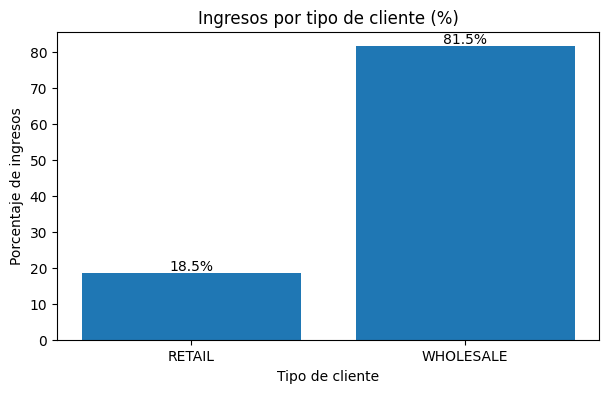

In [485]:
data = orders_work.groupby("customer_type")["monto_total"].sum()
data_pct = data / data.sum() * 100

plt.figure(figsize=(7,4))
bars = plt.bar(data_pct.index, data_pct.values)

plt.title("Ingresos por tipo de cliente (%)")
plt.xlabel("Tipo de cliente")
plt.ylabel("Porcentaje de ingresos")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

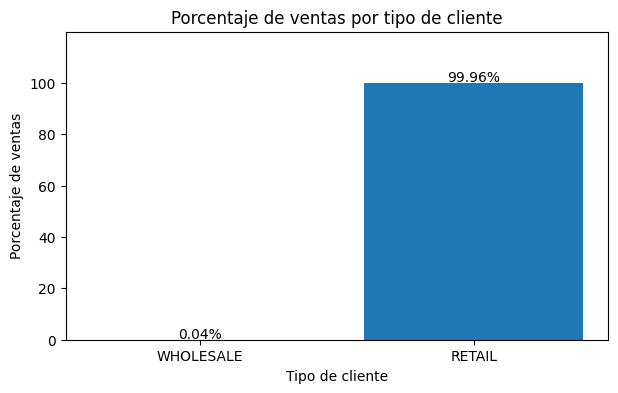

In [486]:
data = orders_work["customer_type"].value_counts(normalize=True) * 100
data = data.sort_values()

plt.figure(figsize=(7,4))
plt.bar(data.index, data.values)

plt.title("Porcentaje de ventas por tipo de cliente")
plt.xlabel("Tipo de cliente")
plt.ylabel("Porcentaje de ventas")

plt.ylim(0, data.max() * 1.2)

for i, v in enumerate(data.values):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha="center")

plt.show()

In [487]:
orders_work.isnull().sum().sum()

0

**📊 DataFrame: catalog_work**
*🧹 Limpieza y preparación de datos*

- Identificación y división de las columnas en variables categóricas y numéricas  
- Limpieza de texto en columnas categóricas (conversión a mayúsculas y eliminación de espacios) 
- Clasificación de productos por costo unitario (para facilitar el análisis)   
- Cálculo del IQR para la toma de decisiones respecto a outliers  

In [488]:
value_counts_multi(
    catalog_work,
    [    
        "nombre_producto",
        "categoria_producto",
        "costo_unitario",
        "proveedor",

    ]
)


====== CATEGÓRICAS ======

--- nombre_producto ---
Blender-XL-Red          1
Sneakers-Urban-42       1
Jacket-Winter-M         1
Laptop-Gaming-16GB      1
Phone-Pro-128GB         1
Vacuum-Pro-Black        1
Tablet-Standard-64GB    1
Name: nombre_producto, dtype: int64

--- categoria_producto ---
Electrónica    3
Moda           2
Hogar          2
Name: categoria_producto, dtype: int64

--- proveedor ---
Mcmillan-Rhodes            1
Long-Reid                  1
Fuller, Pena and Myers     1
Bowers LLC                 1
Greene-Smith               1
Rivera, Carr and Finley    1
King Ltd                   1
Name: proveedor, dtype: int64

====== NUMÉRICAS ======

--- costo_unitario ---
count      7.000000
mean     102.252857
std      111.011563
min       10.120000
25%       16.905000
50%       25.210000
75%      182.975000
max      280.680000
Name: costo_unitario, dtype: float64


In [489]:
clean_text(
    catalog_work,
    ["nombre_producto","categoria_producto","proveedor",]
)


--- nombre_producto ---
PHONE-PRO-128GB         1
LAPTOP-GAMING-16GB      1
VACUUM-PRO-BLACK        1
TABLET-STANDARD-64GB    1
BLENDER-XL-RED          1
SNEAKERS-URBAN-42       1
JACKET-WINTER-M         1
Name: nombre_producto, dtype: int64

--- categoria_producto ---
ELECTRÓNICA    3
HOGAR          2
MODA           2
Name: categoria_producto, dtype: int64

--- proveedor ---
FULLER, PENA AND MYERS     1
LONG-REID                  1
MCMILLAN-RHODES            1
GREENE-SMITH               1
KING LTD                   1
BOWERS LLC                 1
RIVERA, CARR AND FINLEY    1
Name: proveedor, dtype: int64


In [490]:
catalog_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [491]:
catalog_work = segment_product(catalog_work, "costo_unitario")

In [492]:
catalog_work.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor,product_segment
0,LAPTOP-GAMING-16GB,ELECTRÓNICA,280.68,"FULLER, PENA AND MYERS",PREMIUM
1,PHONE-PRO-128GB,ELECTRÓNICA,10.12,KING LTD,LOW-COST
2,TABLET-STANDARD-64GB,ELECTRÓNICA,25.21,BOWERS LLC,MID-RANGE
3,BLENDER-XL-RED,HOGAR,176.64,LONG-REID,PREMIUM
4,VACUUM-PRO-BLACK,HOGAR,16.60,"RIVERA, CARR AND FINLEY",LOW-COST


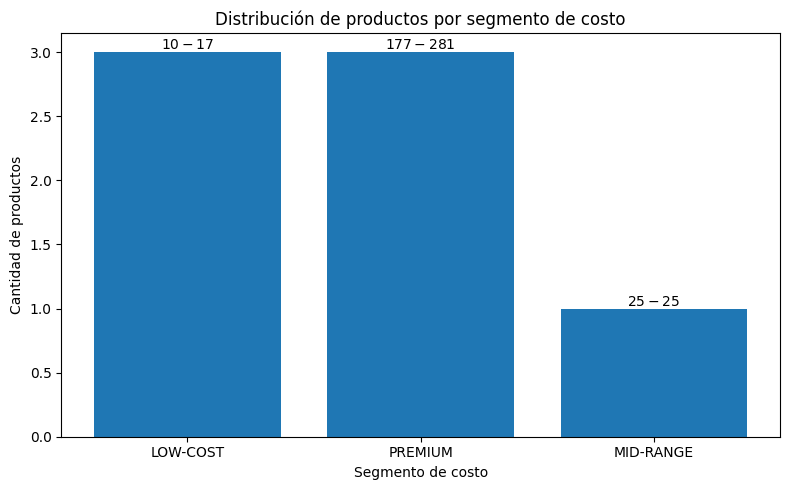

In [493]:
# Conteo por segmento (altura de la barra)
segment_counts = catalog_work["product_segment"].value_counts()

# Min y max por segmento
min_price = catalog_work.groupby("product_segment")["costo_unitario"].min()
max_price = catalog_work.groupby("product_segment")["costo_unitario"].max()

# Alinear con el mismo orden del gráfico
min_price = min_price.reindex(segment_counts.index)
max_price = max_price.reindex(segment_counts.index)

plt.figure(figsize=(8, 5))
bars = plt.bar(segment_counts.index, segment_counts.values)

plt.title("Distribución de productos por segmento de costo")
plt.xlabel("Segmento de costo")
plt.ylabel("Cantidad de productos")

# Labels con rango min - max
for bar, min_p, max_p in zip(bars, min_price, max_price):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${min_p:.0f} - ${max_p:.0f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [494]:
Q1 = catalog_work["costo_unitario"].quantile(0.25)
Q3 = catalog_work["costo_unitario"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

outliers = catalog_work[
    (catalog_work["costo_unitario"] < limite_inferior) |
    (catalog_work["costo_unitario"] > limite_superior)
]

outliers

,nombre_producto,categoria_producto,costo_unitario,proveedor,product_segment


**📊 DataFrame: marketing_work**
*🧹 Limpieza y preparación de datos*


- Identificación y división de las columnas en variables categóricas y numéricas  
- Limpieza de texto en columnas categóricas (conversión a mayúsculas y eliminación de espacios)  
- Reemplazo de valores nulos por la categoría "DESCONOCIDO" en la columna `canal`
- Estandarización de la columna `fecha` a tipo fecha    
- Cálculo del IQR para la toma de decisiones respecto a outliers  


In [495]:
value_counts_multi(
    marketing_work,
    [
        "pais",
        "id_campaña",
        "canal",
        "gasto",
    ]
)


====== CATEGÓRICAS ======

--- pais ---
Mexico       540
Colombia     540
Argentina    540
Name: pais, dtype: int64

--- id_campaña ---
organic_Mexico           180
social_Mexico            180
paid_search_Mexico       180
organic_Colombia         180
social_Argentina         180
organic_Argentina        180
social_Colombia          180
paid_search_Colombia     180
paid_search_Argentina    180
Name: id_campaña, dtype: int64

--- canal ---
paid_search    507
organic        506
social         506
NaN            101
Name: canal, dtype: int64

====== NUMÉRICAS ======

--- gasto ---
count    1620.00000
mean     1772.74292
std       734.43294
min       501.11000
25%      1128.03000
50%      1782.42500
75%      2420.68500
max      2999.36000
Name: gasto, dtype: float64


In [496]:
format_dates(
    marketing_work,
    ["fecha"]
)


--- fecha ---
0   2025-01-01
1   2025-01-01
2   2025-01-01
3   2025-01-01
4   2025-01-01
Name: fecha, dtype: datetime64[ns]
Nulos generados: 0


In [497]:
clean_text(
    marketing_work,
    ["pais","id_campaña","canal",]
)


--- pais ---
MEXICO       540
COLOMBIA     540
ARGENTINA    540
Name: pais, dtype: int64

--- id_campaña ---
ORGANIC_ARGENTINA        180
ORGANIC_MEXICO           180
PAID_SEARCH_COLOMBIA     180
PAID_SEARCH_MEXICO       180
ORGANIC_COLOMBIA         180
SOCIAL_MEXICO            180
PAID_SEARCH_ARGENTINA    180
SOCIAL_ARGENTINA         180
SOCIAL_COLOMBIA          180
Name: id_campaña, dtype: int64

--- canal ---
PAID_SEARCH    507
ORGANIC        506
SOCIAL         506
NaN            101
Name: canal, dtype: int64


In [498]:
fill_unknown(
    marketing_work,
    ["canal"]
)


--- canal ---
PAID_SEARCH    507
ORGANIC        506
SOCIAL         506
DESCONOCIDO    101
Name: canal, dtype: int64


In [499]:
marketing_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


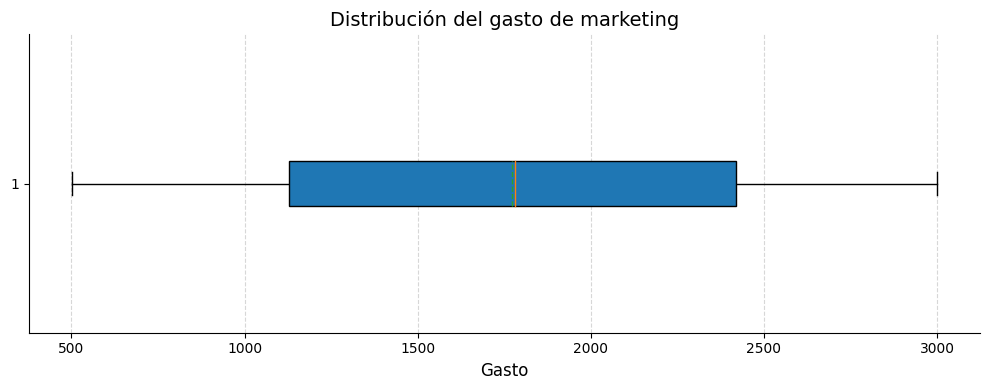

In [500]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    marketing_work["gasto"],
    vert=False,
    patch_artist=True,   # permite rellenar la caja
    showmeans=True,      # muestra la media
    meanline=True        # línea para la media
)

plt.title("Distribución del gasto de marketing", fontsize=14)
plt.xlabel("Gasto", fontsize=12)

# Quitar bordes innecesarios
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [501]:
Q1 = marketing_work["gasto"].quantile(0.25)
Q3 = marketing_work["gasto"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

outliers = marketing_work[
    (marketing_work["gasto"] < limite_inferior) |
    (marketing_work["gasto"] > limite_superior)
]

outliers


,fecha,pais,id_campaña,canal,gasto


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [502]:
# exportar datasets
orders_work.to_csv('orders_work.csv', index=False)
catalog_work.to_csv('catalog_work.csv', index=False)
marketing_work.to_csv('marketing_work.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [503]:
total_revenue = orders_work["monto_total"].sum()

In [504]:
costo_promedio = catalog_work["costo_unitario"].mean()

In [505]:
df_costos = pd.merge(
    orders_work,
    catalog_work[["nombre_producto", "costo_unitario"]],
    on="nombre_producto",
    how="left"
)

In [506]:
df_costos["costo_unitario"] = df_costos["costo_unitario"].fillna(costo_promedio)

In [507]:
df_costos["costo_unitario"].isna().sum()

0

In [508]:
df_costos["costo_total_producto"] = (
    df_costos["cantidad"] * df_costos["costo_unitario"]
)

costo_productos = df_costos["costo_total_producto"].sum()
print(f"Costo productos: ${costo_productos:,.2f}")

Costo productos: $43,128,670.39


In [509]:
costo_marketing = marketing_work["gasto"].sum()

print(f"Costo marketing: ${costo_marketing:,.2f}")

Costo marketing: $2,871,843.53


In [510]:
costo_total = costo_productos + costo_marketing

In [511]:
profit = total_revenue - costo_total

In [512]:
margen = profit / total_revenue

In [513]:
roi = profit / costo_total

In [514]:
print("\033[1m📊 Parte 1: Rentabilidad del negocio\033[0m\n")

print(f"Ingreso total: ${total_revenue:,.2f}")
print(f"Costo marketing: ${costo_marketing:,.2f}")
print(f"Costo total: ${costo_total:,.2f}")
print(f"Profit: ${profit:,.2f}")
print(f"Margen: {margen:.2%}")
print(f"ROI: {roi:.2%}")

📊 Parte 1: Rentabilidad del negocio

Ingreso total: $51,966,981.56
Costo marketing: $2,871,843.53
Costo total: $46,000,513.92
Profit: $5,966,467.64
Margen: 11.48%
ROI: 12.97%


Durante el periodo analizado, la operación generó ingresos por 51.97 M, con costos totales de 46M, resultando en una ganancia neta de 5.97M.

Esto se traduce en un margen de ganancia del 11.48% y un ROI del 12.97%, lo cual posiciona al negocio en una situación de rentabilidad positiva pero con eficiencia moderada.

In [515]:
# Cantidad total de productos por orden
productos_por_orden = orders_work.groupby("id_pedido")["cantidad"].sum()

# Promedio de productos por orden
promedio_productos = productos_por_orden.mean()

print(f"Cantidad promedio de productos por orden: {promedio_productos:.2f}")

Cantidad promedio de productos por orden: 7.12


In [516]:
producto_mas_vendido = (
    orders_work.groupby("nombre_producto")["cantidad"]
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

producto = producto_mas_vendido.index[0]
cantidad = producto_mas_vendido.iloc[0]

print(f"{producto}: {cantidad:,.0f}")

LAPTOP-GAMING-16GB: 144,198


In [517]:
costo_por_pedido = costo_total / len(orders_work)
print(f"Costo por pedido: ${costo_por_pedido:,.2f}")

Costo por pedido: $1,844.00


In [518]:
ticket_promedio = orders_work["monto_total"].mean()
print(f"Ticket promedio: ${ticket_promedio:,.2f}")

Ticket promedio: $2,083.18


In [519]:
gasto_por_canal = marketing_work.groupby("canal")["gasto"].sum().sort_values(ascending=False)

print(gasto_por_canal.apply(lambda x: f"${x:,.2f}"))

canal
SOCIAL         $918,043.21
ORGANIC        $913,533.01
PAID_SEARCH    $863,088.21
DESCONOCIDO    $177,179.10
Name: gasto, dtype: object


In [520]:
df_orders = orders_work.groupby("fuente_referencia")["monto_total"].sum().reset_index()
df_marketing = marketing_work.groupby("canal")["gasto"].sum().reset_index()

df_final = pd.merge(
    df_orders,
    df_marketing,
    left_on="fuente_referencia",
    right_on="canal",
    how="left"
)

df_final["gasto"] = df_final["gasto"].fillna(0)

df_final["contribucion_marketing"] = df_final["monto_total"] - df_final["gasto"]

df_final = df_final.sort_values("contribucion_marketing", ascending=False)

df_final["formateado"] = df_final["contribucion_marketing"].apply(lambda x: f"${x:,.2f}")

print(df_final[["fuente_referencia", "formateado"]])

  fuente_referencia      formateado
2       PAID_SEARCH  $24,364,391.86
3            SOCIAL  $13,308,467.11
1           ORGANIC  $11,587,195.54
0       DESCONOCIDO    $-164,916.48


In [521]:
orders_work[orders_work["fuente_referencia"] == "DESCONOCIDO"]["monto_total"].sum()

12262.619999999999

In [522]:
marketing_work[marketing_work["canal"] == "DESCONOCIDO"]["gasto"].sum()

177179.09999999998

In [523]:
roas = total_revenue / costo_marketing

In [524]:
# Clientes únicos
clientes_unicos = orders_work["id_usuario"].nunique()

# Gasto total en marketing
gasto_total_marketing = marketing_work["gasto"].sum()

# CAC
cac = gasto_total_marketing / clientes_unicos

In [525]:
# Clientes únicos
clientes = orders_work["id_usuario"].nunique()

# Profit por usuario (LTV real)
profit_por_usuario = profit / clientes

# Ratio real
ratio_real = profit_por_usuario / cac

print("\033[1m📈Parte 2: Comportamiento de ventas\033[0m\n")

print(f"Ticket promedio: ${ticket_promedio:,.2f}")
print(f"Cantidad promedio de productos por orden: {promedio_productos:.2f}")
print(f"Producto más vendido: {producto}: {cantidad:,.0f}")
print(f"Profit por usuario: ${profit_por_usuario:,.2f}")
print(f"CAC: ${cac:,.2f}")
print(f"Ratio LTV real / CAC: {ratio_real:.2f}x")
print(f"ROAS: {roas:.2f}")

📈Parte 2: Comportamiento de ventas

Ticket promedio: $2,083.18
Cantidad promedio de productos por orden: 7.12
Producto más vendido: LAPTOP-GAMING-16GB: 144,198
Profit por usuario: $780.95
CAC: $375.90
Ratio LTV real / CAC: 2.08x
ROAS: 18.10


El ROAS de 18.10 indica una alta eficiencia en la generación de ingresos a partir del gasto en marketing. Sin embargo, esta eficiencia no se traduce proporcionalmente en rentabilidad, como lo reflejan el margen del 11.48% y un ratio LTV/CAC de 2.08x.

Esto sugiere que, aunque el marketing está funcionando de manera sobresaliente, la estructura de costos operativos y logísticos limita la captura de valor.

PAID_SEARCH es el canal más poderoso: genera $24.36M netos y es el principal motor de adquisición y revenue. Es el canal con mayor retorno absoluto y eficiencia. SOCIAL es el canal más caro en inversión, pero no el más rentable en retorno.

El canal DESCONOCIDO se encuentra en números negativos por la siguiente posible causa: debido a que se sustituyó los NaN con promedios, el ingreso está siendo insuficiente contra los gastos registrados bajo estás condiciones. 

El producto LAPTOP-GAMING-16GB es un activo estratégico del negocio, ya que concentra un volumen de ventas muy alto. 


**💡 Insights**

**1. Rentabilidad: positiva, pero con presión estructural**

El margen de 11.48% podría indicar que el negocio logra capturar valor, pero dentro de un rango relativamente ajustado.

En modelos tipo delivery, esto es relevante porque:
- los costos logísticos (última milla) son elevados
- las promociones y descuentos son frecuentes
- el costo de adquisición de clientes (CAC) es alto

**2. Estructura de costos: el principal punto de tensión**

El hecho de que los costos representen aproximadamente 88.5% de los ingresos podría indicar una estructura intensiva en gasto.

Esto típicamente implicaría:

-fuerte inversión en marketing para sostener demanda
-subsidios a usuarios (descuentos)
-costos operativos/logísticos significativos

**3. ROI: crecimiento con eficiencia limitada**

Un ROI de 12.97% podría indicar que la inversión genera retorno positivo, pero no de forma altamente eficiente.

Esto sugiere que el negocio está creciendo, pero no de forma orgánica completamente. Parte del crecimiento está siendo impulsado por inversión constante.

**4. Equilibrio crecimiento vs rentabilidad**

Este tipo de negocio suele enfrentarse a una tensión estructural:

Crecer rápido → más marketing → menor margen

Optimizar rentabilidad → menos inversión → menor crecimiento

**5. Alta eficiencia en adquisición y monetización pero no en rentabilidad** 

El ROAS de 18.10 indica una alta eficiencia en la generación de ingresos a partir del gasto en marketing. Sin embargo, esta eficiencia no se traduce proporcionalmente en rentabilidad, como lo reflejan el margen del 11.48% y un ratio LTV/CAC de 2.08x.

Esto sugiere que, aunque el marketing está funcionando de manera sobresaliente, la estructura de costos operativos y logísticos limita la captura de valor.

**6. Dependencia comercial**

El hecho de que un solo producto (LAPTOP-GAMING-16GB) concentre un volumen tan alto de ventas introduce riesgo de dependencia comercial. Esto podría afectar la estabilidad del ingreso si cambian las condiciones de ese producto (precio, disponibilidad o demanda).

**7. Dependencia de ingresos en wholesale frente a un retail de alto volumen pero bajo valor**

Modelo híbrido donde coexisten dos dinámicas claramente diferenciadas: retail funciona como un motor de volumen y recurrencia, mientras que wholesale actúa como el principal generador de ingresos y flujo de caja. Esta dualidad implica que ambos segmentos cumplen roles estratégicos distintos dentro del negocio.





**⚠️ Riesgos estratégicos**

**1. Dependencia del gasto en marketing**

Si el ROI no mejora:
- cada nuevo usuario cuesta relativamente caro
- el crecimiento puede volverse insostenible

**2. Escalabilidad limitada**

Si los costos crecen al mismo ritmo que los ingresos, el negocio escala en volumen pero no en rentabilidad.

**3. Falsa sensación de eficiencia**

Puede llevar a decisiones de sobreinversión en marketing. El peso operativo del segmento retail representa un riesgo de eficiencia. Aunque genera casi la totalidad de las transacciones, su baja contribución relativa a los ingresos sugiere que podría estar consumiendo recursos logísticos y operativos de forma intensiva sin una rentabilidad proporcional, lo que puede erosionar márgenes.

**4. Alta concentración de ingresos en el segmento wholesale**

La dependencia de pocos clientes implica que la pérdida de uno o varios de ellos podría tener un impacto desproporcionado en los ingresos totales, afectando directamente la estabilidad financiera y el flujo de caja del negocio.

**5. Desbalance en la estrategia comercial**

El alto volumen de retail puede llevar a enfocar esfuerzos en este segmento por su visibilidad operativa, mientras que wholesale, siendo el principal generador de ingresos, podría no estar recibiendo la atención estratégica necesaria en términos de gestión de cuentas, retención y crecimiento.





**📝Recomendaciones**

**1. Optimizar la eficiencia del gasto en marketing**
Reevaluar la asignación del presupuesto de marketing enfocándose en canales y campañas con mayor rentabilidad.

**2. Mejorar la rentabilidad unitaria antes de escalar**
Implementar iniciativas orientadas a incrementar el margen por cliente (pricing, reducción de costos logísticos, optimización operativa) antes de aumentar agresivamente la adquisición, asegurando que el crecimiento sea rentable.

**2. Incremento del ticket promedio**
Optimizar el modelo operativo del segmento retail mediante automatización, mejora en ticket promedio y control de costos, con el objetivo de disminuir su carga operativa y mejorar su contribución al margen.

**4. Diversificar la base de clientes wholesale**
Desarrollar estrategias de adquisición y retención para ampliar el portafolio de clientes wholesale, reduciendo la concentración de ingresos y mitigando el riesgo asociado a la pérdida de cuentas clave.

**5. Implementar una estrategia comercial diferenciada por segmento**
Separar claramente la gestión de retail y wholesale:

Retail → eficiencia, automatización y escalabilidad
Wholesale → gestión de cuentas, relaciones y crecimiento de valor

**6. Priorizar la retención y expansión de clientes de alto valor**
Enfocar esfuerzos en maximizar el valor de clientes existentes (especialmente wholesale) mediante estrategias de upselling, fidelización y contratos de largo plazo.

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [526]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [527]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


**📊 DataFrame: events**
*🧹 Limpieza y preparación de datos*

-Se realizó la validación de registros duplicados utilizando las columnas id_usuario, id_sesion, nombre_evento y timestamp_evento → **No se identificaron registros duplicados**

-Se verificó la existencia de valores nulos en las mismas columnas → **No se encontraron valores faltantes**

-Se calculó el número de usuarios y sesiones únicas

-Se analizó la cantidad de sesiones por usuario → **No se observaron comportamientos atípicos ni outliers relevantes**

-Se evaluó el número de eventos por sesión → **No se detectaron anomalías en la distribución**


In [528]:
query_duplicates = '''
SELECT 
    id_usuario,
    id_sesion,
    nombre_evento,
    timestamp_evento,
    COUNT(*) AS duplicados
FROM events
GROUP BY 
    id_usuario,
    id_sesion,
    nombre_evento,
    timestamp_evento
HAVING COUNT(*) > 1;
'''

duplicates = pd.read_sql(query_duplicates, con=engine)

duplicates.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,duplicados


In [529]:
events.duplicated(subset=[
    'id_usuario',
    'id_sesion',
    'nombre_evento',
    'timestamp_evento'
]).sum()

0

In [530]:
query_nulls = '''
SELECT 
    SUM(CASE WHEN id_usuario IS NULL THEN 1 ELSE 0 END) AS null_id_usuario,
    SUM(CASE WHEN id_sesion IS NULL THEN 1 ELSE 0 END) AS null_id_sesion,
    SUM(CASE WHEN nombre_evento IS NULL THEN 1 ELSE 0 END) AS null_nombre_evento,
    SUM(CASE WHEN timestamp_evento IS NULL THEN 1 ELSE 0 END) AS null_timestamp_evento
FROM events;
'''

pd.read_sql(query_nulls, con=engine)

,null_id_usuario,null_id_sesion,null_nombre_evento,null_timestamp_evento
0,0,0,0,0


In [531]:
query_unique = '''
SELECT 
    COUNT(DISTINCT id_usuario) AS usuarios_unicos,
    COUNT(DISTINCT id_sesion) AS sesiones_unicas
FROM events;
'''

pd.read_sql(query_unique, con=engine)

,usuarios_unicos,sesiones_unicas
0,8000,120000


**🔍 Definición del funnel**
- Dado que no se contaba con una definición previa del funnel para RappiPlus, este fue construido a partir del comportamiento real de los usuarios.
- Debido a la alta variabilidad en las secuencias de eventos, no fue adecuado utilizar directamente los recorridos completos de los usuarios. En su lugar, se definió el funnel a partir de eventos clave, validando su orden temporal por usuario.
Este enfoque permite medir el avance de los usuarios de manera más robusta y realista.
- La disminución de usuarios entre cada etapa del funnel es esperada, ya que se aplican validaciones estrictas de secuencia. Esto implica que se excluyen usuarios con eventos fuera de orden o journeys inconsistentes.
- Inicialmente, se consideró un enfoque basado en agregaciones tipo pivot, pero fue descartado debido a que este método rompe la secuencia de eventos al tratar cada uno de manera independiente.
La solución final consiste en reconstruir el journey completo de cada usuario y evaluar el funnel de forma secuencial, asegurando que se respete el orden correcto de los eventos.

In [532]:
unique_users_per_event = (
    events
    .groupby('nombre_evento')['id_usuario']
    .nunique()
    .reset_index(name='unique_users')
    .sort_values('unique_users', ascending=False)
)

unique_users_per_event

,nombre_evento,unique_users
3,first_visit,7796
1,add_to_cart,7634
5,select_item,7582
2,begin_checkout,7208
0,add_payment_info,6250
4,purchase,6240


In [533]:
query = '''
SELECT 
    id_usuario,
    COUNT(DISTINCT id_sesion) AS sesiones_por_usuario
FROM events
GROUP BY id_usuario
ORDER BY sesiones_por_usuario DESC;
'''

df_sessions = pd.read_sql(query, con=engine)
df_sessions.head(10)

,id_usuario,sesiones_por_usuario
0,user_159,33
1,user_2800,32
2,user_3279,31
3,user_834,31
4,user_5849,31
5,user_592,30
6,user_6986,30
7,user_4594,30
8,user_2641,30
9,user_4147,29


In [534]:
query = '''
SELECT 
    id_sesion,
    COUNT(*) AS eventos_por_sesion
FROM events
GROUP BY id_sesion
ORDER BY eventos_por_sesion DESC;
'''

df_events_session = pd.read_sql(query, con=engine)
df_events_session.head(10)

,id_sesion,eventos_por_sesion
0,2bf0b7e0-819d-431b-9c0f-4f83fdfc0a95,1
1,16f12c35-8136-482a-b46c-b1fddeef0c6e,1
2,766f6792-28e6-43b1-a666-5da86b15a1e4,1
3,a3e34900-bb36-4644-aacd-f7a84db350ec,1
4,32cf4b8e-15dc-4aba-a8e7-fb0ca31f3211,1
5,efd93d72-b679-4578-9946-0de668890460,1
6,860576e0-730f-45c4-a1f3-59b4f20f88c5,1
7,decfdfba-b6d2-4d89-8be2-60fe056b6ee0,1
8,0b32d6b2-1a6b-4cb3-9333-5fde06308fe1,1
9,e98f2049-f1d5-4477-9742-eee8a36073c1,1


In [535]:
# 1. Ordenar eventos por usuario y tiempo
df = events.sort_values(['id_usuario', 'timestamp_evento']).copy()

# 2. Eliminar eventos repetidos consecutivos
df['prev_event'] = df.groupby('id_usuario')['nombre_evento'].shift()

df_clean = df[
    (df['nombre_evento'] != df['prev_event']) | (df['prev_event'].isna())
].copy()

# 3. Construir el path completo por usuario
paths = (
    df_clean
    .groupby('id_usuario')['nombre_evento']
    .apply(lambda x: ' -> '.join(x))
    .reset_index(name='path')
)

# 4. Encontrar los funnels más comunes
funnel_paths = (
    paths
    .groupby('path')
    .size()
    .reset_index(name='usuarios')
    .sort_values('usuarios', ascending=False)
)

# 5. Ver el funnel dominante
funnel_paths.head(10)

,path,usuarios
4112,first_visit -> add_to_cart -> first_visit -> s...,2
6978,select_item -> add_to_cart -> select_item -> f...,2
7497,select_item -> first_visit -> add_to_cart -> s...,2
5981,purchase -> first_visit -> add_payment_info ->...,2
3922,first_visit -> add_to_cart -> begin_checkout -...,2
5331,first_visit -> select_item -> begin_checkout -...,1
5327,first_visit -> select_item -> begin_checkout -...,1
5328,first_visit -> select_item -> begin_checkout -...,1
5329,first_visit -> select_item -> begin_checkout -...,1
5330,first_visit -> select_item -> begin_checkout -...,1


In [536]:
# ordenar eventos
df = events.sort_values(['id_usuario', 'timestamp_evento']).copy()

# agrupar eventos por usuario como lista ordenada
user_events = (
    df.groupby('id_usuario')['nombre_evento']
    .apply(list)
    .reset_index()
)

# definir pasos
steps = [
    'first_visit',
    'select_item',
    'add_to_cart',
    'begin_checkout',
    'add_payment_info',
    'purchase'
]

# función estricta de funnel
def strict_funnel(events, steps):
    result = []
    idx = 0
    
    for step in steps:
        found = False
        for i in range(idx, len(events)):
            if events[i] == step:
                idx = i + 1
                found = True
                break
        result.append(1 if found else 0)
    
    return result

# aplicar
user_events[steps] = user_events['nombre_evento'].apply(
    lambda x: pd.Series(strict_funnel(x, steps))
)

# construir resultado
funnel_result = pd.DataFrame({
    'step': steps,
    'usuarios': [user_events[s].sum() for s in steps]
})

# conversiones
funnel_result['conversion_rate'] = funnel_result['usuarios'] / funnel_result['usuarios'].shift(1)
funnel_result.loc[0, 'conversion_rate'] = 1
funnel_result['conversion_rate'] *= 100

# drop-off
funnel_result['drop_off'] = funnel_result['usuarios'].shift(1) - funnel_result['usuarios']
funnel_result['drop_off_rate'] = 100 - funnel_result['conversion_rate']

funnel_result

,step,usuarios,conversion_rate,drop_off,drop_off_rate
0,first_visit,7796,100.000000,NaN,0.000000
1,select_item,6910,88.635198,886.0,11.364802
2,add_to_cart,5904,85.441389,1006.0,14.558611
3,begin_checkout,4194,71.036585,1710.0,28.963415
4,add_payment_info,2594,61.850262,1600.0,38.149738
5,purchase,2140,82.498072,454.0,17.501928


In [537]:
worst_step = funnel_result.sort_values('drop_off_rate', ascending=False).iloc[0]

worst_step

step               add_payment_info
usuarios                       2594
conversion_rate           61.850262
drop_off                     1600.0
drop_off_rate             38.149738
Name: 4, dtype: object

In [538]:
total_conversion = (
    funnel_result.loc[funnel_result['step'] == 'purchase', 'usuarios'].values[0] /
    funnel_result.loc[funnel_result['step'] == 'first_visit', 'usuarios'].values[0]
) * 100

print(f"Conversión total: {total_conversion:.2f}%")

Conversión total: 27.45%


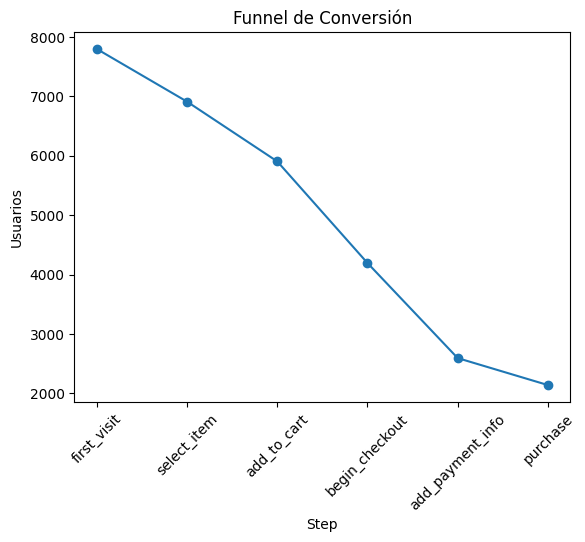

In [539]:
plt.figure()
plt.plot(funnel_result['step'], funnel_result['usuarios'], marker='o')
plt.xticks(rotation=45)
plt.title('Funnel de Conversión')
plt.xlabel('Step')
plt.ylabel('Usuarios')
plt.show()

**💡 Insights**

El análisis del funnel muestra un volumen inicial de 7,796 usuarios en first_visit, con una conversión final de aproximadamente 27.4% hasta compra, lo cual indica que poco más de una cuarta parte de los usuarios completa el proceso. Las primeras etapas del funnel presentan un desempeño sólido, con una conversión del 88.6% de first_visit a select_item y 85.4% hacia add_to_cart, lo que sugiere que la propuesta de valor inicial y la exploración de productos funcionan adecuadamente.

Sin embargo, a partir de begin_checkout se observa una caída significativa en el comportamiento de los usuarios. El paso más crítico ocurre entre begin_checkout y add_payment_info, donde se registra el mayor abandono del funnel con un drop-off del 38.1%, equivalente a 1,600 usuarios. Esto indica que existe una fricción relevante en la etapa de pago, posiblemente relacionada con la experiencia de usuario, métodos de pago o percepción de seguridad. A pesar de esto, la conversión final de add_payment_info a purchase es relativamente alta (82.5%), lo que sugiere que una vez que el usuario ingresa su información de pago, la probabilidad de completar la compra es elevada.


**⚠️ Riesgos estratégicos**

El principal riesgo identificado es la fricción en la etapa de pago, específicamente antes de que los usuarios ingresen su información de pago. Este comportamiento puede estar impactando directamente los ingresos potenciales, ya que una proporción significativa de usuarios con alta intención de compra abandona en esta etapa crítica. Además, la caída relevante desde begin_checkout podría indicar problemas estructurales en el flujo de checkout, como procesos largos, falta de claridad en costos adicionales (envío, tarifas) o limitaciones en métodos de pago disponibles.

Otro riesgo es la posible pérdida de confianza del usuario en esta etapa final del funnel, lo cual podría afectar no solo la conversión inmediata, sino también la recurrencia futura. Si la experiencia de pago no es fluida, los usuarios podrían optar por alternativas competidoras con procesos más simples o transparentes.


**📝Recomendaciones**

Se recomienda priorizar la optimización del flujo de checkout, enfocándose especialmente en la transición de begin_checkout a add_payment_info. Algunas acciones clave incluyen simplificar el proceso de pago, reducir el número de pasos necesarios, mejorar la visibilidad de costos finales desde etapas tempranas y asegurar que los métodos de pago disponibles sean amplios y confiables para los usuarios.

Adicionalmente, sería valioso implementar análisis segmentados por variables como dispositivo, país o fuente de adquisición para identificar si la fricción está concentrada en ciertos grupos de usuarios. Esto permitiría diseñar soluciones más específicas y efectivas. Finalmente, se sugiere realizar pruebas A/B sobre mejoras en la experiencia de checkout, así como monitorear métricas de abandono en tiempo real para validar el impacto de los cambios implementados.

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`


**📊 Tablas: `users` y `user_activity`**
*🧹 Limpieza y preparación de datos*

Se realizó un proceso de limpieza y validación de datos con el objetivo de garantizar la consistencia y confiabilidad del análisis de cohortes.

**🔹 Limpieza de la tabla users**
- Eliminación de duplicados por id_usuario, conservando el primer registro
- Eliminación de valores nulos en campos críticos (id_usuario, fecha_registro)
- Conversión de fecha_registro a formato DATE
- Estandarización de variables categóricas (país, dispositivo, tipo_plan) mediante UPPER y TRIM

**🔹 Limpieza de la tabla user_activity**
- Eliminación de duplicados por combinación id_usuario + fecha_actividad
- Eliminación de valores nulos en campos críticos (id_usuario, fecha_actividad)
- Conversión de fecha_actividad a formato DATE
- Normalización de la variable activo a formato binario (0/1)

**🔹 Validación e integración de datos**
- Unión de ambas tablas mediante id_usuario
- Eliminación de registros de actividad sin correspondencia en la tabla de usuarios
- Eliminación de actividades previas a la fecha de registro del usuario

**🔹 Ingeniería de variables**
- Re-cálculo de la variable dias_despues_registro como la diferencia entre fecha_actividad y fecha_registro, evitando inconsistencias en el dato original
- Generación de un dataset final limpio y consistente para el análisis de cohortes


In [540]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [541]:
query = """
SELECT 
    MIN(fecha_registro) AS primera_fecha,
    MAX(fecha_registro) AS ultima_fecha
FROM users;
"""
pd.read_sql(query, engine)

,primera_fecha,ultima_fecha
0,2025-01-01,2025-05-31


In [542]:
query = """
SELECT COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM users;
"""
pd.read_sql(query, engine)

,usuarios_unicos
0,8000


In [543]:
query = """
SELECT COUNT(*) AS total_registros
FROM users;
"""
pd.read_sql(query, engine)

,total_registros
0,8000


In [544]:
query = """
SELECT
    COUNT(*) AS total,
    COUNT(*) FILTER (WHERE id_usuario IS NULL) AS null_id,
    COUNT(*) FILTER (WHERE fecha_registro IS NULL) AS null_fecha,
    COUNT(*) FILTER (WHERE país IS NULL) AS null_pais,
    COUNT(*) FILTER (WHERE dispositivo IS NULL) AS null_dispositivo,
    COUNT(*) FILTER (WHERE tipo_plan IS NULL) AS null_plan
FROM users;
"""
pd.read_sql(query, engine)

,total,null_id,null_fecha,null_pais,null_dispositivo,null_plan
0,8000,0,0,0,0,0


In [545]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [546]:
query = """
SELECT 
    MIN(fecha_actividad) AS primera_fecha,
    MAX(fecha_actividad) AS ultima_fecha
FROM user_activity;
"""
pd.read_sql(query, engine)

,primera_fecha,ultima_fecha
0,2025-01-08,2025-06-28


In [547]:
query = """
WITH users_clean AS (
    SELECT
        id_usuario,
        CAST(fecha_registro AS DATE) AS fecha_registro,

        -- limpieza de texto
        UPPER(TRIM(país)) AS país,
        UPPER(TRIM(dispositivo)) AS dispositivo,
        UPPER(TRIM(tipo_plan)) AS tipo_plan

    FROM (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY id_usuario 
                   ORDER BY fecha_registro
               ) AS rn
        FROM users
    ) t
    WHERE rn = 1
      AND id_usuario IS NOT NULL
      AND fecha_registro IS NOT NULL
),

-- limpieza completa de activity
ua_clean AS (
    SELECT
        id_usuario,
        CAST(fecha_actividad AS DATE) AS fecha_actividad,

        -- normalizar activo
        CASE 
            WHEN activo = 1 THEN 1
            ELSE 0
        END AS activo

    FROM (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY id_usuario, fecha_actividad
                   ORDER BY fecha_actividad
               ) AS rn
        FROM user_activity
        WHERE id_usuario IS NOT NULL
          AND fecha_actividad IS NOT NULL
    ) t
    WHERE rn = 1
),

-- consistencia + feature engineering
ua_final AS (
    SELECT
        ua.id_usuario,
        ua.fecha_actividad,
        u.fecha_registro,

        -- recalcular días correctamente
        (ua.fecha_actividad - u.fecha_registro) AS dias_despues_registro,

        ua.activo,

        -- opcional: mantener variables limpias de users
        u.país,
        u.dispositivo,
        u.tipo_plan

    FROM ua_clean ua
    JOIN users_clean u
        ON ua.id_usuario = u.id_usuario

    -- eliminar actividad inválida
    WHERE ua.fecha_actividad >= u.fecha_registro
)

SELECT *
FROM ua_final
LIMIT 50;
"""

df_clean = pd.read_sql(query, engine)
df_clean.head()

,id_usuario,fecha_actividad,fecha_registro,dias_despues_registro,activo,país,dispositivo,tipo_plan
0,user_0,2025-02-05,2025-01-29,7,0,MEXICO,MOBILE,FREE
1,user_0,2025-02-12,2025-01-29,14,1,MEXICO,MOBILE,FREE
2,user_0,2025-02-19,2025-01-29,21,1,MEXICO,MOBILE,FREE
3,user_0,2025-02-26,2025-01-29,28,0,MEXICO,MOBILE,FREE
4,user_1,2025-01-14,2025-01-07,7,0,MEXICO,MOBILE,FREE


In [548]:
query = """
WITH users_clean AS (
    SELECT
        id_usuario,
        CAST(fecha_registro AS DATE) AS fecha_registro,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE)) AS cohorte_mes
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY id_usuario ORDER BY fecha_registro) AS rn
        FROM users
    ) t
    WHERE rn = 1
),

ua_clean AS (
    SELECT
        id_usuario,
        CAST(fecha_actividad AS DATE) AS fecha_actividad,
        activo
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY id_usuario, fecha_actividad
                   ORDER BY fecha_actividad
               ) AS rn
        FROM user_activity
    ) t
    WHERE rn = 1
),

ua_joined AS (
    SELECT
        ua.id_usuario,
        u.cohorte_mes,
        u.fecha_registro,
        ua.fecha_actividad,
        (ua.fecha_actividad - u.fecha_registro) AS dias,
        CASE WHEN ua.activo = 1 THEN 1 ELSE 0 END AS activo
    FROM ua_clean ua
    JOIN users_clean u
        ON ua.id_usuario = u.id_usuario
    WHERE ua.fecha_actividad >= u.fecha_registro
),

-- asignar semana
ua_weeks AS (
    SELECT
        id_usuario,
        cohorte_mes,
        FLOOR(dias / 7) AS semana,
        activo
    FROM ua_joined
),

-- actividad por usuario (pivot lógico)
user_weeks AS (
    SELECT
        id_usuario,
        cohorte_mes,
        MAX(CASE WHEN semana = 1 AND activo = 1 THEN 1 ELSE 0 END) AS w1,
        MAX(CASE WHEN semana = 2 AND activo = 1 THEN 1 ELSE 0 END) AS w2,
        MAX(CASE WHEN semana = 3 AND activo = 1 THEN 1 ELSE 0 END) AS w3
    FROM ua_weeks
    GROUP BY id_usuario, cohorte_mes
),

-- aplicar lógica de supervivencia
survival AS (
    SELECT
        cohorte_mes,
        COUNT(*) AS usuarios_iniciales,

        SUM(CASE WHEN w1 = 1 THEN 1 ELSE 0 END) AS retenido_w1,

        SUM(CASE WHEN w1 = 1 AND w2 = 1 THEN 1 ELSE 0 END) AS retenido_w2,

        SUM(CASE WHEN w1 = 1 AND w2 = 1 AND w3 = 1 THEN 1 ELSE 0 END) AS retenido_w3

    FROM user_weeks
    GROUP BY cohorte_mes
)

SELECT
    cohorte_mes,
    usuarios_iniciales,

    retenido_w1,
    retenido_w2,
    retenido_w3,

    ROUND(retenido_w1 * 100.0 / usuarios_iniciales, 2) AS semana_1,
    ROUND(retenido_w2 * 100.0 / usuarios_iniciales, 2) AS semana_2,
    ROUND(retenido_w3 * 100.0 / usuarios_iniciales, 2) AS semana_3

FROM survival
ORDER BY cohorte_mes;
"""

df_survival = pd.read_sql(query, engine)
df_survival

,cohorte_mes,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01 00:00:00+00:00,1627,697,340,146,42.84,20.90,8.97
1,2025-02-01 00:00:00+00:00,1444,611,267,129,42.31,18.49,8.93
2,2025-03-01 00:00:00+00:00,1636,677,300,133,41.38,18.34,8.13
3,2025-04-01 00:00:00+00:00,1606,680,314,146,42.34,19.55,9.09
4,2025-05-01 00:00:00+00:00,1687,695,299,151,41.20,17.72,8.95


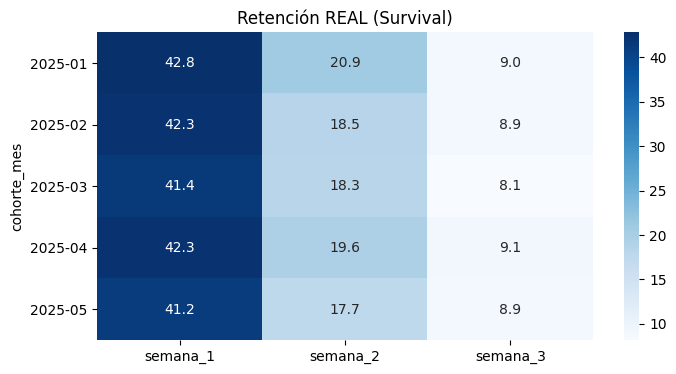

In [549]:
df_plot = df_survival.set_index('cohorte_mes')[['semana_1','semana_2','semana_3']]

# Formato YYYY-MM
df_plot.index = pd.to_datetime(df_plot.index).strftime('%Y-%m')

plt.figure(figsize=(8,4))
sns.heatmap(df_plot, annot=True, fmt=".1f", cmap="Blues")

plt.title("Retención REAL (Survival)")
plt.yticks(rotation=0)

plt.show()

In [550]:
df_survival['cohorte_mes'] = pd.to_datetime(df_survival['cohorte_mes'])

print("Primera cohorte:", df_survival['cohorte_mes'].min())
print("Última cohorte:", df_survival['cohorte_mes'].max())

Primera cohorte: 2025-01-01 00:00:00+00:00
Última cohorte: 2025-05-01 00:00:00+00:00


**💡 Insights**

El análisis de cohortes revela un patrón consistente en el comportamiento de retención de usuarios entre enero y mayo de 2025.

La retención en semana 1 se mantiene estable en torno al 41%–43%, lo que indica un buen nivel de activación inicial tras el registro.
Sin embargo, se observa una caída significativa hacia la semana 2, donde la retención disminuye aproximadamente a 18%–21%, lo que implica la pérdida de más del 50% de los usuarios activos iniciales.
Para la semana 3, la retención se reduce aún más a niveles cercanos al 8%–9%, mostrando que solo una pequeña proporción de usuarios mantiene un uso continuo del producto.

Adicionalmente:

No se observan mejoras progresivas entre cohortes, lo que sugiere ausencia de optimizaciones recientes en retención.
El comportamiento es altamente consistente entre meses, indicando un patrón estructural más que un evento aislado.

**⚠️ Riesgos Estratégicos**

**1. Abandono temprano**

Usuarios adquieren o prueban el servicio, pero no desarrollan hábito.

**2. Baja recurrencia en pedidos**

El modelo pierde eficiencia porque: Menos pedidos → menor monetización → menor ROI del usuario

**3. Riesgo en ingresos por suscripción**

Si los usuarios no perciben valor rápidamente:
- No existe retención de suscriptores
- Pérdida de ingresos recurrentes

**4. Ineficiencia en adquisición de usuarios**

Con este nivel de churn temprano:

- Gran parte del presupuesto de adquisición (marketing) se desperdicia

**5. Falta de diferenciación percibida**

- No hay mejoras visibles en la experiencia o el producto no está evolucionando en términos de engagement


📝**Recomendaciones**

**1. Optimizar el onboarding** para mejorar la retención en la semana 2.
   
**2. Impulsar la activación temprana** (primeros 7 días) mediante notificaciones push, emails de re-engagement e incentivos de uso inicial, con el objetivo de reducir la caída entre la semana 1 y la semana 2.

**3. Identificar usuarios de alto valor.** A partir del análisis de los usuarios que llegan a la semana 3, replicar sus patrones de comportamiento en nuevos usuarios.

**4. Segmentar el análisis de retención** por país, dispositivo y tipo de plan, para detectar los segmentos con mejor desempeño y escalar las estrategias más efectivas.

**5. Implementar medición continua y experimentación mediante pruebas A/B** en onboarding, comunicación y funcionalidades clave.

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

In [551]:
# Cargar dataset
df= pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

# Información general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [552]:
df.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


**📊 Dataset: experiment_checkout_ui** 🧹 Limpieza y preparación de datos

- Limpieza de texto en columnas categóricas (conversión a mayúsculas y eliminación de espacios)
-Estandarización de la columna `timestamp` a tipo fecha
- Eliminación de registros duplicados (no se encontraron duplicados)

In [553]:
cols_to_clean = ['variante', 'dispositivo', 'pais']
clean_text(df, cols_to_clean)


--- variante ---
TRATAMIENTO    5035
CONTROL        4965
Name: variante, dtype: int64

--- dispositivo ---
DESKTOP    5042
MOBILE     4958
Name: dispositivo, dtype: int64

--- pais ---
MEXICO       3405
ARGENTINA    3317
COLOMBIA     3278
Name: pais, dtype: int64


In [554]:
format_dates(df, ['timestamp'])


--- timestamp ---
0   2025-03-28
1   2025-01-15
2   2025-03-18
3   2025-06-03
4   2025-01-12
Name: timestamp, dtype: datetime64[ns]
Nulos generados: 0


In [555]:
df = remove_duplicates(df, cols=['id_usuario'])

Rows before: 10000
Rows after: 10000
Duplicates removed: 0


In [556]:
conversion_rates = df.groupby('variante')['convirtio'].mean()
print(conversion_rates)

variante
CONTROL        0.156898
TRATAMIENTO    0.162860
Name: convirtio, dtype: float64


In [557]:
summary = df.groupby('variante')['convirtio'].agg(['mean', 'count', 'sum'])
summary.columns = ['conversion_rate', 'usuarios', 'conversiones']
print(summary)

             conversion_rate  usuarios  conversiones
variante                                            
CONTROL             0.156898      4965           779
TRATAMIENTO         0.162860      5035           820


**🧾Hipótesis**

**H₀ (Hipótesis nula):**

No hay diferencia en la tasa de conversión entre las variantes del checkout.
(p_control = p_treatment)

**H₁ (Hipótesis alternativa):**

Sí hay diferencia en la tasa de conversión entre las variantes.
(p_control ≠ p_treatment)

📊**Selección del test estadístico**

Se utilizó un **Z-test de proporciones** debido a que la variable de interés (convirtio) es binaria y se comparan dos grupos independientes (variante). Además, el tamaño de muestra es suficientemente grande, lo que permite aplicar este test para evaluar si la diferencia en tasas de conversión es estadísticamente significativa.

In [558]:
from statsmodels.stats.proportion import proportions_ztest

# Conversiones
conversions = df.groupby('variante')['convirtio'].sum()

# Total usuarios
n = df.groupby('variante')['convirtio'].count()

print(conversions)
print(n)

variante
CONTROL        779
TRATAMIENTO    820
Name: convirtio, dtype: int64
variante
CONTROL        4965
TRATAMIENTO    5035
Name: convirtio, dtype: int64


In [559]:
count = conversions.values
nobs = n.values

stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {stat}")
print(f"P-value: {p_value}")

Z-statistic: -0.8132782986429474
P-value: 0.41605851639119995


In [560]:
alpha = 0.05

In [561]:
if p_value < alpha:
    print("Rechazamos H0: hay diferencia significativa entre las variantes")
else:
    print("No se puede rechazar H0: no hay evidencia de diferencia significativa")

No se puede rechazar H0: no hay evidencia de diferencia significativa


**🧾 Conclusión**

El p-value obtenido (0.416) es mayor que el nivel de significancia (α = 0.05), por lo tanto, no se rechaza la hipótesis nula. Esto indica que no existe evidencia estadísticamente significativa para afirmar que la variante del checkout tenga un impacto en la tasa de conversión. Las diferencias observadas entre los grupos pueden atribuirse al azar.

*Aunque se observa una ligera diferencia entre variantes, esta no es estadísticamente significativa, por lo que no se recomienda implementar cambios basados en este experimento.*

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_work.csv`  
- `catalog_work.csv`  
- `marketing_work.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [562]:
https://drive.google.com/drive/u/0/folders/1JxLDqi0PmP3ZN0xOv54vP05PBvOoyC9s?q=sharedwith:public%20parent:1JxLDqi0PmP3ZN0xOv54vP05PBvOoyC9s